# Knee MRI in 11 GiB

**TL;DR.** Keep all training studies, store fewer pixels. The primary download contains **all 4,407 training studies in 11.12 GiB of uint8 pixels**, without keeping roughly 500 GB of DICOM resident: six scan slots, nine slices per slot, 224 × 224 pixels, keeping a central region about 130 × 130 mm when cropping applies. These are training studies, not a count of unique people or the combined train and test sets.

- Independent image probe: **0.660 held-out macro AUC** (95% interval 0.633–0.689), on the same fixed 200 studies and five study folds.
- 224² → 336²: 2.25× the storage for an observed +0.005 AUC; the gain is uncertain, not a proven flat plateau.
- Three slices scored lower, but this verifier did not establish a clear quality cliff. Treat the earlier slice-cliff claim as provisional.
- **This is a storage and geometry result, not a medal.** It makes no leaderboard or foundation-model claim.

**[Download the primary cache](https://www.kaggle.com/datasets/dmitriigluzdov/rsna-knee-uint8-224-9-c130)** · Derived competition MRI; use is subject to the competition rules and MIRA terms.


## What we measured

We changed image resolution, slice count, or physical crop while keeping the study subset, labels, folds, and classifier fixed. A **slot** is one of six combinations of scan plane and the official `Fluid_Sensitive` flag. Nine slices means three groups of three neighboring images.

| What changes | What it means | What stays fixed |
| --- | --- | --- |
| Resolution: 128² to 336² | Resize the selected image to that many pixels per side using bilinear interpolation. More pixels give a finer grid, not a higher JPEG quality setting. | Nine slices; requested 130 mm crop |
| Slices: 3 to 15 per slot | Retain more or fewer images along the scan stack. | 224² pixels; requested 130 mm crop |
| Crop: 110 / 130 / 160 mm | **Side length of the central square we keep**, not the amount removed. Crop first, then resize. | 224² pixels; nine slices; identical storage |

All variants use the same eight-bit intensity conversion: clip the bottom/top 1% within each sampled, cropped series, then map to 0–255. We did not sweep bit depth or JPEG compression. Smaller resolution reduces the pixel count; smaller crop changes which anatomy those pixels cover.

The verifier reads **spatial edge maps and small image grids**, then fits a regularized linear classifier—a model whose weights are constrained to limit overfitting. It uses every retained slice at its cache resolution. This replaces the old model that saw only eight summary numbers per slot; it is a fixed image descriptor, not a pretrained or learned image encoder.

**Protocol:** 200 studies, exactly 40 from each locked `FOLDS_V1` fold; study-level five-fold validation; seed 2026. Targets are the 12 Pilkwang `report_labels_v2.csv` scores, binarized at 0.5. Every study is predicted by a model trained on the other folds. **Macro AUC** is the equal-weight average of the 12 target ranking scores; 0.5 is chance ranking and 1.0 is perfect ranking.

Error bars use 800 study resamples. Differences use the **same resampled studies** for both settings. These intervals do not include retraining or alternative-fold uncertainty. We call two settings practically equivalent only if their whole paired interval fits inside **±0.01 AUC**. A sanity check with randomly shuffled labels scored **0.486**. No settings were chosen using leaderboard scores.

Each of the 15 settings is now **built directly from sampled DICOM pixels**. The previous resolution sweep resized already converted eight-bit 336² images; this correction makes the 224² point match the downloadable cache. Within each sampled, cropped series, the lowest and highest 1% of intensities are clipped before scaling to one byte per pixel. Physical order uses image position along the slice stack, with `SliceLocation` and then `InstanceNumber` as fallbacks.


In [ ]:
import base64,gzip
from pathlib import Path
_ = Path('/kaggle/working/folds.csv').write_bytes(gzip.decompress(base64.b64decode('...')))


In [ ]:
"""CPU-only image verifier and report-free MRI cache. Geometry attribution: NOTICE.md."""
from __future__ import annotations

import gc
import hashlib
import json
import os
import platform
import time
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import scipy
from scipy.ndimage import zoom
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from threadpoolctl import threadpool_limits

SEED = 2026
FOLDS_SHA = "3086df3341333f44adb883292da386857c3230eaa2d501514ddf827a2da11b1a"
LABELS_SHA = "6f704a7bdb2f894cc49445b19ba7c4378c3f548d3449e00361e10044bee40920"
TARGETS = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA",
           "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"]
SLOTS = [("SAG_FLUID", "Sagittal", 1), ("COR_FLUID", "Coronal", 1),
         ("AX_FLUID", "Axial", 1), ("SAG_STRUCT", "Sagittal", 0),
         ("COR_STRUCT", "Coronal", 0), ("AX_STRUCT", "Axial", 0)]
DEFAULT = "res_224x9_c130"
DATASET = "dmitriigluzdov/rsna-knee-uint8-224-9-c130"
GIB = 4407 * 6 * 9 * 224 ** 2 / 1024 ** 3
THREADS = min(8, os.cpu_count() or 2)
START = time.time()


def log(message):
    print(f"[{time.time()-START:.0f}s] {message}", flush=True)


def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 << 20), b""):
            h.update(block)
    return h.hexdigest()


def save_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, allow_nan=False) + "\n", encoding="utf-8")


def competition_root():
    for p in [Path("/kaggle/input/rsna-knee-abnormality-detection"),
              Path("/kaggle/input/competitions/rsna-knee-abnormality-detection")]:
        if (p / "train_series.csv").exists():
            return p
    raise FileNotFoundError("Attach the official RSNA knee competition")


def variants():
    rows = []
    def add(vid, family, img, slices, crop, window=(.35, .65)):
        rows.append(dict(id=vid, family=family, img=img, n_slices=slices,
                         crop_mm=crop, window=list(window),
                         full_corpus_gib=4407*6*slices*img**2/1024**3))
    for img in [128,160,192,224,256,288,336]:
        add(f"res_{img}x9_c130", "resolution", img, 9, 130)
    for n in [3,6,12,15]:
        add(f"slc_224x{n}_c130", "slices", 224, n, 130)
    for crop in [110,160]:
        add(f"crp_224x9_c{crop}", "crop", 224, 9, crop)
    for img in [160,128]:
        add(f"tiny_{img}x3_c130", "tiny", img, 3, 130, (.40,.60))
    return rows


def finite_vector(value, n):
    try:
        a = np.asarray(value, dtype=float)
        return a if a.shape == (n,) and np.isfinite(a).all() else None
    except (ValueError, TypeError):
        return None


def order_files(paths, audit):
    """Physical projection, then SliceLocation, then InstanceNumber; fail if unordered."""
    headers = [pydicom.dcmread(p, stop_before_pixels=True, specific_tags=[
        "ImagePositionPatient", "ImageOrientationPatient", "SliceLocation",
        "InstanceNumber", "PixelSpacing"], force=True) for p in paths]
    normal = None
    for ds in headers:
        ori = finite_vector(getattr(ds, "ImageOrientationPatient", None), 6)
        if ori is not None:
            v = np.cross(ori[:3], ori[3:])
            if np.linalg.norm(v) > 1e-6:
                normal = v / np.linalg.norm(v)
                break
    positions = [finite_vector(getattr(d, "ImagePositionPatient", None), 3) for d in headers]
    keys = None
    if normal is not None and all(p is not None for p in positions):
        keys = [float(p @ normal) for p in positions]
        audit["order_geometry"] += 1
    else:
        for tag in ["SliceLocation", "InstanceNumber"]:
            vals = [finite_vector([getattr(d, tag, None)], 1) for d in headers]
            if all(v is not None for v in vals):
                keys = [float(v[0]) for v in vals]
                audit["order_" + tag] += 1
                break
    if keys is None:
        if len(paths) == 1:
            keys = [0.]
            audit["single_slice_series"] += 1
        else:
            raise ValueError("Series lacks all physical-order fallback tags")
    idx = sorted(range(len(paths)), key=lambda i: (keys[i], paths[i].name))
    spacing = finite_vector(getattr(headers[idx[0]], "PixelSpacing", None), 2)
    if spacing is not None and not np.isclose(spacing[0], spacing[1], rtol=.001):
        audit["anisotropic_spacing_series"] += 1
    return [paths[i] for i in idx], None if spacing is None else float(spacing[0])


def sample_indices(n, n_slices, window):
    if n < 1 or n_slices < 3 or n_slices % 3:
        raise ValueError("Require nonempty series and groups of three")
    lo, hi = [int(f*(n-1)) for f in window]
    if hi <= lo:
        lo, hi = 0, n-1
    anchors = (np.linspace(lo, hi, n_slices//3).astype(int) if n_slices > 3
               else np.array([(lo+hi)//2]))
    indices = []
    for anchor in anchors:
        start = int(np.clip(anchor-1, 0, max(0,n-3)))
        indices.extend(range(start, min(start+3,n)))
    indices += [indices[-1]] * (n_slices-len(indices))
    return indices[:n_slices]


def load_series(root, frame, audit, configs):
    """Decode the union of required slices once. Never read reports or free text."""
    records = {}
    for name, plane, fluid in SLOTS:
        cand = frame[(frame.Anatomical_Plane == plane) & (frame.Fluid_Sensitive.astype(int) == fluid)]
        choices = []
        for row in cand.itertuples(index=False):
            d = root / "train_series" / row.StudyInstanceUID / row.SeriesInstanceUID
            paths = sorted(d.glob("*.dcm")) if d.is_dir() else []
            # Keep CSV order for equal counts, matching the original locked probe.
            choices.append((len(paths), paths, str(row.SeriesInstanceUID)))
        if not choices:
            audit["absent_slots"] += 1
            continue
        _, paths, sid = max(choices, key=lambda x: x[0])
        if not paths:
            raise FileNotFoundError(f"Metadata series has no DICOM files: {sid}")
        paths, spacing = order_files(paths, audit)
        needed = sorted(set(i for c in configs for i in sample_indices(len(paths), c["n_slices"], c["window"])))
        pixels = {}
        for i in needed:
            ds = pydicom.dcmread(paths[i], force=True)
            a = ds.pixel_array.astype(np.float32)
            if a.ndim != 2 or not np.isfinite(a).all():
                raise ValueError(f"Unsupported or nonfinite pixels: {paths[i].name}")
            a = a * float(getattr(ds, "RescaleSlope", 1)) + float(getattr(ds, "RescaleIntercept", 0))
            if str(getattr(ds,"PhotometricInterpretation", "")).strip() == "MONOCHROME1":
                a = a.max() - a
                audit["mono1_inverted"] += 1
            pixels[i] = a
            audit["slices_read"] += 1
        records[name] = dict(n=len(paths), pixels=pixels, spacing=spacing, series_uid=sid)
    return records


def render_slot(rec, cfg, audit):
    idx = sample_indices(rec["n"], cfg["n_slices"], cfg["window"])
    vol = np.stack([rec["pixels"][i] for i in idx])
    px = rec["spacing"]
    if px is not None and np.isfinite(px) and px > 0:
        want = int(round(cfg["crop_mm"] / px))
        h,w = vol.shape[-2:]
        if 16 < want < min(h,w):
            half = want//2
            vol = vol[:,h//2-half:h//2+half,w//2-half:w//2+half]
            audit["crop_applied"] += 1
        else:
            audit["crop_skipped_fov"] += 1
    else:
        audit["crop_missing_spacing"] += 1
    # Same sampled-series percentile scope as the previous probe and credited geometry.
    low,high = np.percentile(vol,[1,99])
    vol = np.clip((vol-low)/max(high-low,1e-6),0,1)
    img = cfg["img"]
    vol = zoom(vol, (1,img/vol.shape[1],img/vol.shape[2]), order=1,
               mode="nearest", prefilter=False, grid_mode=True)
    result = np.clip(np.rint(vol*255),0,255).astype(np.uint8)
    assert result.shape == (cfg["n_slices"],img,img)
    return result


def pool_grid(x, grid=8):
    h,w = x.shape[-2:]
    assert h%grid == w%grid == 0
    return x.reshape(*x.shape[:-2],grid,h//grid,grid,w//grid).mean(axis=(-3,-1))


def encode_slot(vol):
    """Unsigned oriented gradients at native resolution; no learned/full-data preprocessing."""
    x = vol.astype(np.float32)/255
    gy,gx = np.gradient(x, axis=(-2,-1))
    magnitude = np.hypot(gx,gy)
    angle = np.mod(np.arctan2(gy,gx),np.pi) * (8/np.pi)
    low = np.floor(angle).astype(np.int32)%8
    fraction = angle - np.floor(angle)
    maps = []
    for k in range(8):
        weight = (low==k)*(1-fraction) + ((low+1)%8==k)*fraction
        maps.append(pool_grid(magnitude*weight))
    hist = np.stack(maps,axis=1)
    hist /= np.sqrt((hist**2).sum(axis=1,keepdims=True)+1e-8)
    hist = np.minimum(hist,.2)
    hist /= np.sqrt((hist**2).sum(axis=1,keepdims=True)+1e-8)
    desc = np.concatenate([hist.reshape(len(x),-1),pool_grid(x).reshape(len(x),-1)],axis=1)
    # Three fixed depth bins give all geometries the same feature dimension.
    return np.stack([v.mean(axis=0) for v in np.array_split(desc,3)]).ravel().astype(np.float32)


def encode_study(records, cfg, audit):
    features,mask = [],[]
    for name,_,_ in SLOTS:
        if name in records:
            features.append(encode_slot(render_slot(records[name],cfg,audit)))
            mask.append(1.)
        else:
            features.append(np.zeros(3*9*8*8,np.float32))
            mask.append(0.)
    return np.concatenate(features+[np.asarray(mask,np.float32)])


def macro_auc(y,p):
    values = [roc_auc_score(y[:,j],p[:,j]) for j in range(y.shape[1])
              if np.unique(y[:,j]).size == 2]
    return float(np.mean(values)) if values else float("nan")


def oof_predict(x,y,folds):
    pred = np.full(y.shape,np.nan,np.float64)
    with threadpool_limits(limits=2):
        for fold in range(5):
            tr,va = folds!=fold,folds==fold
            assert tr.any() and va.any() and not np.any(tr&va)
            scale = StandardScaler()
            a = scale.fit_transform(x[tr]).astype(np.float64)
            b = scale.transform(x[va]).astype(np.float64)
            model = Ridge(alpha=1000.,solver="cholesky")
            model.fit(a,y[tr])
            pred[va] = model.predict(b)
    assert np.isfinite(pred).all()
    return pred


def locked_subset(folds_path, labels_path):
    assert sha256(folds_path)==FOLDS_SHA, "FOLDS_V1 changed"
    assert sha256(labels_path)==LABELS_SHA, "Pilkwang label version changed"
    folds = pd.read_csv(folds_path)
    labels = pd.read_csv(labels_path,usecols=["StudyInstanceUID"]+TARGETS)
    assert folds.StudyInstanceUID.is_unique and labels.StudyInstanceUID.is_unique
    picked = []
    rng = np.random.default_rng(SEED)
    for fold in range(5):
        ids = folds.loc[folds.fold==fold,"StudyInstanceUID"].tolist()
        rng.shuffle(ids)
        picked.extend(ids[:40])
    subset = pd.DataFrame({"StudyInstanceUID":picked}).merge(folds,validate="one_to_one")
    subset = subset.merge(labels,how="left",validate="one_to_one")
    assert subset[TARGETS].notna().all().all(), "Subset includes missing labels"
    scores = subset[TARGETS].to_numpy(float)
    assert np.isfinite(scores).all()
    y = (scores>=.5).astype(np.int32)
    return subset[["StudyInstanceUID","fold"]],y


def paired_statistics(y,predictions):
    # Multinomial bootstrap weights preserve identical study resamples for every cache.
    # Weighted rank AUC computes 800 replicates without repeated sklearn calls.
    rng = np.random.default_rng(SEED+1)
    weights = rng.multinomial(len(y),np.ones(len(y))/len(y),size=800).astype(float)
    def draws(pred):
        out = []
        for j in range(y.shape[1]):
            order = np.argsort(pred[:,j],kind="stable")
            yy = y[order,j]
            pp = pred[order,j]
            ww = weights[:,order]
            pos,neg = ww*yy,ww*(1-yy)
            cum = np.cumsum(neg,axis=1)-neg
            # Include half of negative weight tied at the same prediction value.
            starts = np.r_[0,np.flatnonzero(np.diff(pp))+1]
            ends = np.r_[starts[1:],len(pp)]
            for a,b in zip(starts,ends):
                cum[:,a:b] = (neg[:,:a].sum(axis=1)+.5*neg[:,a:b].sum(axis=1))[:,None]
            denom = pos.sum(axis=1)*neg.sum(axis=1)
            out.append(np.divide((pos*cum).sum(axis=1),denom,
                                 out=np.full(len(weights),np.nan),where=denom>0))
        return np.nanmean(out,axis=0)
    boot = {key:draws(p) for key,p in predictions.items()}
    reference = boot[DEFAULT]
    result = {}
    for key,p in predictions.items():
        delta = boot[key]-reference
        result[key] = dict(auc=macro_auc(y,p),ci95_lo=float(np.percentile(boot[key],2.5)),
            ci95_hi=float(np.percentile(boot[key],97.5)),
            delta_auc=macro_auc(y,p)-macro_auc(y,predictions[DEFAULT]),
            delta_ci95_lo=float(np.percentile(delta,2.5)),
            delta_ci95_hi=float(np.percentile(delta,97.5)),
            paired_p=min(1.,2*min((np.sum(delta<=0)+1)/801,(np.sum(delta>=0)+1)/801)))
    others = sorted((k for k in result if k!=DEFAULT),key=lambda k:result[k]["paired_p"])
    adjusted = 0.
    for rank,key in enumerate(others):
        adjusted = max(adjusted,min(1.,(len(others)-rank)*result[key]["paired_p"]))
        result[key]["holm_p"] = adjusted
    result[DEFAULT]["holm_p"] = 1.
    return result


def verify_curve(root,folds_path,labels_path,out):
    out = Path(out); out.mkdir(parents=True,exist_ok=True)
    subset,y = locked_subset(folds_path,labels_path)
    subset.to_csv(out/"subset.csv",index=False)
    configs = variants()
    series = pd.read_csv(root/"train_series.csv",usecols=["StudyInstanceUID","SeriesInstanceUID","Anatomical_Plane","Fluid_Sensitive"])
    groups = {uid:g for uid,g in series.groupby("StudyInstanceUID",sort=False)}
    def one(uid):
        audit = Counter()
        records = load_series(root,groups[uid],audit,configs)
        encoded,per_variant = {},{}
        for cfg in configs:
            ca = Counter()
            encoded[cfg["id"]] = encode_study(records,cfg,ca)
            per_variant[cfg["id"]] = dict(ca)
        return encoded,audit,per_variant
    features = {c["id"]:[] for c in configs}
    audit = Counter(); crop_audits = {c["id"]:Counter() for c in configs}
    with ThreadPoolExecutor(max_workers=min(4,THREADS)) as pool:
        for i,(encoded,counts,per_variant) in enumerate(pool.map(one,subset.StudyInstanceUID)):
            audit.update(counts)
            for key in features:
                features[key].append(encoded[key]); crop_audits[key].update(per_variant[key])
            if (i+1)%10==0:
                log(f"Image descriptors: {i+1}/200 studies")
    predictions = {}
    folds = subset.fold.to_numpy()
    for cfg in configs:
        key = cfg["id"]
        x = np.stack(features[key])
        predictions[key] = oof_predict(x,y,folds)
        if key==DEFAULT:
            perm = np.random.default_rng(SEED+99).permutation(len(y))
            control = macro_auc(y[perm],oof_predict(x,y[perm],folds))
        log(f"{key}: OOF macro AUC {macro_auc(y,predictions[key]):.4f}")
    stats = paired_statistics(y,predictions)
    rows = [dict(c,**stats[c["id"]],**crop_audits[c["id"]]) for c in configs]
    metrics = pd.DataFrame(rows)
    metrics.to_csv(out/"verifier_metrics.csv",index=False)
    np.savez_compressed(out/"verifier_oof.npz",y=y,folds=folds,**predictions)
    per_target = []
    for key,p in predictions.items():
        for j,target in enumerate(TARGETS):
            per_target.append(dict(id=key,target=target,auc=roc_auc_score(y[:,j],p[:,j]),positives=int(y[:,j].sum())))
    pd.DataFrame(per_target).to_csv(out/"per_target.csv",index=False)
    pd.DataFrame([dict(id=key,fold=f,auc=macro_auc(y[folds==f],p[folds==f]))
                  for key,p in predictions.items() for f in range(5)]).to_csv(out/"per_fold.csv",index=False)
    import sklearn
    receipt = dict(model="Spatial oriented-gradient encoder + Ridge(alpha=1000)",
        feature_dim=len(features[DEFAULT][0]),n_subset=len(y),folds_sha256=FOLDS_SHA,
        labels_sha256=LABELS_SHA,subset_sha256=sha256(out/"subset.csv"),seed=SEED,
        n_bootstrap=800,permutation_control_auc=control,decode_audit=dict(audit),
        versions=dict(python=platform.python_version(),numpy=np.__version__,scipy=scipy.__version__,
                      sklearn=sklearn.__version__,pydicom=pydicom.__version__),
        elapsed_seconds=time.time()-START,default=DEFAULT,rows=rows)
    save_json(out/"verifier_receipt.json",receipt)
    # Render separately in the public notebook.
    return receipt


def plot_curve(metrics,out):
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
    base = metrics[metrics.id==DEFAULT]
    fig,ax = plt.subplots(figsize=(9,5.8))
    for family,marker,color,label in [("resolution","o","#2364aa","Resolution · 9 slices"),
                                     ("slices","s","#d16b28","Slice count · 224 × 224")]:
        d = metrics[metrics.family==family]
        if family=="slices": d = pd.concat([d,base])
        d = d.sort_values("full_corpus_gib")
        ax.errorbar(d.full_corpus_gib,d.auc,
            yerr=np.maximum(0,np.array([d.auc-d.ci95_lo,d.ci95_hi-d.auc])),
            fmt=marker+"-",color=color,capsize=3,label=label)
        for r in d.itertuples():
            text = str(r.img) if family=="resolution" else f"{r.n_slices} slices"
            ax.annotate(text,(r.full_corpus_gib,r.auc),xytext=(0,9 if family=="resolution" else -17),
                        textcoords="offset points",ha="center",fontsize=8,color=color)
    tiny = metrics[metrics.family=="tiny"]
    ax.scatter(tiny.full_corpus_gib,tiny.auc,marker="^",color=".5",label="3-slice extras · narrower window")
    ax.axvline(GIB,color=".3",ls=":",label="Primary cache · 11.12 GiB")
    ax.set(xlabel="Estimated pixel storage for all 4,407 studies (GiB)",
           ylabel="Held-out macro AUC",title="A · Quality versus storage — crop 130 mm")
    ax.grid(alpha=.15); ax.legend(fontsize=9,loc="best")
    large = metrics[metrics.id=='res_336x9_c130'].iloc[0]
    fig.text(.08,.035,
        f"224 → 336 pixels: +{large.full_corpus_gib-GIB:.2f} GiB for observed {large.delta_auc:+.3f} AUC\n"
        f"Paired 95% interval: {large.delta_ci95_lo:+.3f} to {large.delta_ci95_hi:+.3f} · gain uncertain; flat plateau not proven",
        fontsize=10,color='.25')
    fig.tight_layout(rect=(0,.13,1,1)); fig.savefig(Path(out)/"figure_A.png",dpi=170); plt.show(); plt.close(fig)
    fig,ax = plt.subplots(figsize=(8,5.6))
    d = pd.concat([base,metrics[metrics.family=="crop"]]).sort_values("crop_mm")
    ax.errorbar(d.crop_mm,d.auc,yerr=np.maximum(0,np.array([d.auc-d.ci95_lo,d.ci95_hi-d.auc])),
                fmt="o",color="#2364aa",capsize=5,markersize=8)
    for r in d.itertuples():
        ax.annotate(f"{r.auc:.3f}",(r.crop_mm,r.auc),xytext=(10,0),textcoords="offset points")
    ax.set(xticks=[110,130,160],xlim=(100,175),
           xlabel="Requested side length KEPT (mm), then resized to 224 × 224\n← tighter view / larger anatomy in pixels     wider view / more context →",
           ylabel="Held-out macro AUC",title="B · What to keep in frame — same 11.12 GiB")
    tight = metrics[metrics.id=='crp_224x9_c110'].iloc[0]
    fig.text(.09,.025,
        f"110 mm scores highest; advantage over 130 mm is uncertain.\n"
        f"Paired difference: {tight.delta_auc:+.3f} [{tight.delta_ci95_lo:+.3f}, {tight.delta_ci95_hi:+.3f}].\n"
        "Crop is skipped when the source field of view is too small.",fontsize=10,color='.25')
    ax.grid(alpha=.15);fig.tight_layout(rect=(0,.18,1,1));fig.savefig(Path(out)/"figure_B.png",dpi=170);plt.show();plt.close(fig)


def materialize(root,out,study_limit=None):
    """One dense uint8 cache in ~323 MiB .npy shards; explicit absent-slot mask."""
    out = Path(out);out.mkdir(parents=True,exist_ok=True)
    cfg = next(c for c in variants() if c["id"]==DEFAULT)
    studies = pd.read_csv(root/"train.csv",usecols=["StudyInstanceUID"])
    assert studies.StudyInstanceUID.is_unique and len(studies)==4407
    studies = studies.sort_values("StudyInstanceUID").reset_index(drop=True)
    if study_limit is not None: studies = studies.iloc[:study_limit]
    series = pd.read_csv(root/"train_series.csv",usecols=["StudyInstanceUID","SeriesInstanceUID","Anatomical_Plane","Fluid_Sensitive"])
    groups = {uid:g for uid,g in series.groupby("StudyInstanceUID",sort=False)}
    def one(uid):
        audit = Counter();records = load_series(root,groups[uid],audit,[cfg])
        pixels = np.zeros((6,9,224,224),np.uint8)
        mask = np.zeros(6,np.uint8)
        for j,(name,_,_) in enumerate(SLOTS):
            if name in records:
                pixels[j] = render_slot(records[name],cfg,audit);mask[j]=1
        if mask.sum()==0: raise ValueError(f"No usable slots for study {uid}")
        return pixels,mask,audit
    manifest=[];shards=[];audit=Counter();masks=[]
    for start in range(0,len(studies),128):
        ids = studies.StudyInstanceUID.iloc[start:start+128].tolist()
        filename=f"pixels-{start//128:03d}.npy"
        path=out/filename
        array=np.lib.format.open_memmap(path,mode="w+",dtype=np.uint8,shape=(len(ids),6,9,224,224))
        with ThreadPoolExecutor(max_workers=THREADS) as pool:
            for row,(pixels,mask,counts) in enumerate(pool.map(one,ids)):
                array[row]=pixels;masks.append(mask);audit.update(counts)
                manifest.append(dict(StudyInstanceUID=ids[row],shard=filename,row=row))
        array.flush();del array
        check=np.load(path,mmap_mode="r",allow_pickle=False)
        assert check.dtype==np.uint8 and check.shape==(len(ids),6,9,224,224)
        del check
        shards.append(dict(file=filename,n_studies=len(ids),bytes=path.stat().st_size,sha256=sha256(path)))
        log(f"Cache: {start+len(ids)}/{len(studies)} studies; {filename} verified")
    pd.DataFrame(manifest).to_csv(out/"studies.csv",index=False)
    np.save(out/"slot_mask.npy",np.stack(masks),allow_pickle=False)
    save_json(out/"AUDIT.json",dict(audit))
    aux={p.name:sha256(p) for p in [out/"studies.csv",out/"slot_mask.npy",out/"AUDIT.json"]}
    spec=dict(img=224,n_slices=9,group=3,n_group=3,crop_mm=130,window=[.35,.65],
        slot_scheme=[dict(name=n,plane=p,Fluid_Sensitive=f) for n,p,f in SLOTS],
        dtype="uint8",n_studies=len(studies),shape_per_study=[6,9,224,224],
        pixel_bytes=len(studies)*6*9*224**2,pixel_gib=len(studies)*6*9*224**2/1024**3,
        shards=shards,sha256={**{s["file"]:s["sha256"] for s in shards},**aux},
        ordering=["ImagePositionPatient projected on orientation normal","SliceLocation","InstanceNumber"],
        unordered_policy="fail",decode_error_policy="fail; never substitute broken DICOM with zero",
        missing_slot_policy="zero-filled with explicit slot_mask.npy; no series for public plane/Fluid_Sensitive slot",
        series_choice="most DICOM files; CSV order breaks ties",
        percentile_scope="1st-99th percentile over the sampled cropped volume, independently per series",
        crop_policy="center crop using row PixelSpacing; skip if crop >= shorter FOV or spacing missing; no padding",
        interpolation="scipy.ndimage.zoom(order=1, grid_mode=True, mode=nearest); round to uint8",
        photometric="apply RescaleSlope/Intercept and invert MONOCHROME1",
        source="rsna-knee-abnormality-detection official training MRI",
        data_license="Competition rules + RSNA MIRA; private, participating users only",
        geometry_license="Apache-2.0; Steven Lee; see NOTICE.md",
        lossless=False,dataset_url="https://www.kaggle.com/datasets/"+DATASET)
    save_json(out/"SPEC.json",spec)
    assert len(manifest)==len(studies) and len(set(m["StudyInstanceUID"] for m in manifest))==len(studies)
    return spec


def run_all(folds_path, evidence_dir, cache_dir):
    root=competition_root()
    hits=list(Path("/kaggle/input").glob("**/report_labels_v2.csv"))
    assert len(hits)==1, "Attach exactly one Pilkwang report_labels_v2.csv"
    receipt=verify_curve(root,Path(folds_path),hits[0],Path(evidence_dir))
    # Cache default is fixed before measurement. Strong contrary evidence is flagged,
    # never silently used to tune a recipe or discard a completed experiment.
    contrary=[r["id"] for r in receipt["rows"] if r["delta_ci95_lo"]>.01 and r["holm_p"]<.05]
    if contrary: log("Review clearly better alternatives before publication: "+str(contrary))
    gc.collect()
    spec=materialize(root,Path(cache_dir))
    log(f"Complete: {spec['n_studies']} studies, {spec['pixel_gib']:.5f} GiB of uint8 pixels")
    return receipt,spec


In [ ]:
from IPython.utils.capture import capture_output
with capture_output() as build_log:
    receipt,spec=run_all('/kaggle/working/folds.csv', '/kaggle/working/evidence', '/kaggle/temp/rsna-knee-cache')
_ = Path('/kaggle/working/build.log').write_text(build_log.stdout,encoding='utf-8')
_ = Path('/kaggle/temp/rsna-knee-cache/NOTICE.md').write_text("# Source and use\n\nMRI pixels are derived from the official RSNA Knee Abnormality Detection training\ndata. They remain subject to the [competition rules](https://www.kaggle.com/competitions/rsna-knee-abnormality-detection/rules)\nand [RSNA MIRA licence](http://rsna.org/mira-license). This private cache is for\ncompetition participants who have accepted those terms. Do not redistribute to\nnon-participants. It is not a substitute for the official train zip or lossless DICOM.\n\nGeometry credit: Steven Lee,\n[RSNA Knee: 500GB to 11GiB CPU Pixel Cache](https://www.kaggle.com/code/stevenleehans/rsna-knee-500gb-to-11gib-cpu-pixel-cache),\nApache License 2.0. His notebook credits Pilkwang's slot scheme, Karnakbayev's\nthree-slice grouping, and Will's physical crop. The new pipeline reimplements\nphysical ordering, slice grouping, millimetre center cropping, percentile scaling,\nand uint8 caching. Modifications: public train_series flags; native SciPy bilinear\nresize; explicit absent-slot mask; fail on decoding/order errors; sharded NumPy\nfiles; spatial gradient verifier with study-level validation. No report parsing or\nreport lexicon code is included or copied. Apache-2.0 covers geometry code, not\npermission to redistribute MRI. See LICENSE-APACHE-2.0.txt.\n\nNo radiology reports, train.csv, report lexicon, or report-derived labels are\nincluded in the cache Dataset. Label scores are used only to evaluate the probe.\n",encoding='utf-8')
_ = Path('/kaggle/temp/rsna-knee-cache/LICENSE-APACHE-2.0.txt').write_text('\n                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or\n          Derivative Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n',encoding='utf-8')


## Plots

**A** separates resolution from slice count, with crop fixed at 130 mm. Storage is the full 4,407-study pixel payload, not the 200-study probe size or a compressed archive download. The vertical line marks the primary cache. Gray triangles are the original three-slice extras with a narrower sampling window; they are not connected to the controlled families.

**B** compares the **width of the region kept**: 110, 130, or 160 mm, each resized to 224² × 9. Every point uses the same 11.12 GiB. Left means a tighter view; right means a wider view, not automatically better quality. Error bars show uncertainty in AUC, not image sharpness.


In [ ]:
plot_curve(pd.read_csv('/kaggle/working/evidence/verifier_metrics.csv'),Path('/kaggle/working/evidence'))


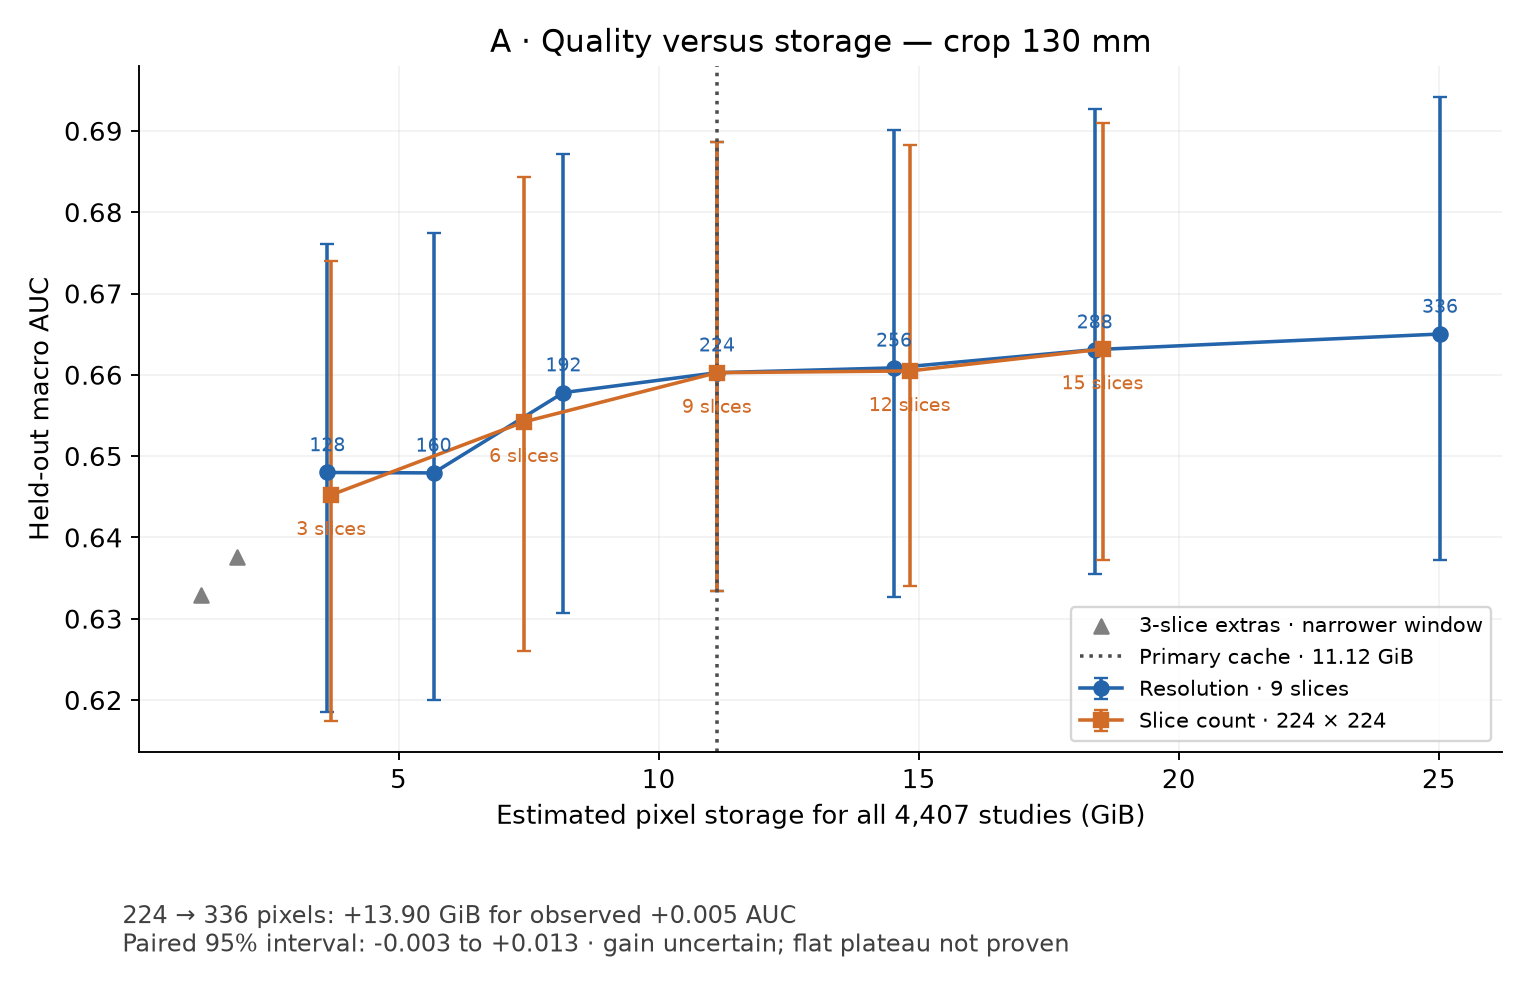

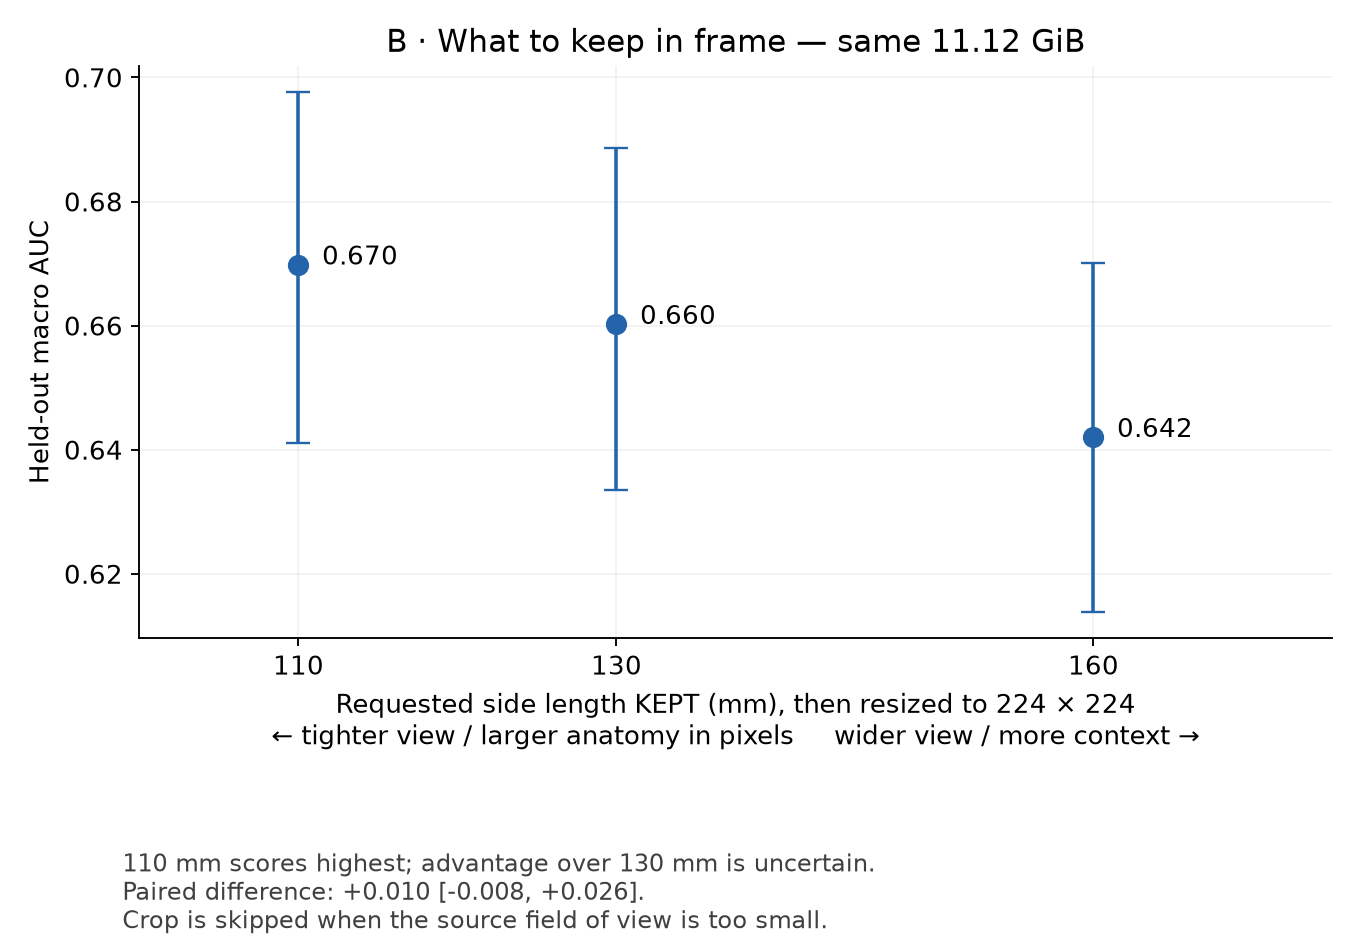

Figures from the completed CPU verifier run. Save & Run regenerates both PNGs.


**How to read A: diminishing returns, not a proven plateau.** The resolution curve still rises: **0.660 → 0.665 AUC**, while storage rises **11.12 → 25.02 GiB**. That is another **13.90 GiB** for an observed **+0.005 AUC**, with a paired 95% interval of **-0.003 to +0.013**. The interval includes zero and a potentially useful gain: neither a reliable improvement nor strict equivalence is established. We keep 224² as a storage compromise. The existing 256² and 288² points already fill the gap; more resolution settings would not fix uncertainty from evaluating only 200 studies.

Three slices scored lower, but this verifier did not establish a clear quality cliff. Treat the earlier slice-cliff claim as provisional. Three slices change AUC by **-0.015**, with a paired 95% interval of **-0.030 to +0.001**. We keep nine slices, but do not present the old “only real quality cliff” claim as established by this model.

160² × 9 uses 5.67 GiB; its paired AUC difference is -0.012 [-0.019, -0.005]. This does not prove equivalence within ±0.01 AUC. Allowing for the fact that we compared 14 alternatives still leaves evidence that 160² scored lower. The earlier claim that 160² is indistinguishable does not hold for this model. Only the primary 224² cache is published.

**How to read B: more context competes with detail.** Both a 110 mm and a 160 mm square end up as 224 × 224 pixels. When the requested crop applies, a 10 mm structure spans roughly **20 pixels at 110 mm**, versus **14 pixels at 160 mm**. The tighter view spends more pixels on central anatomy but discards more of the periphery. The wider view keeps more context but represents the same structure with fewer pixels. Neither must win. Resizing cannot create detail absent from the original scan.

**110 mm has the highest measured AUC, but is not a confirmed winner.** It scores **0.670**, versus **0.660** at 130 mm: difference **+0.010**, paired 95% interval **-0.008 to +0.026**. A tighter view may suit this edge-based verifier; sampling uncertainty may also explain the difference. This experiment does not identify the cause or establish the best crop for a trained image encoder. We retain the prespecified 130 mm compromise.

The 160 mm crop changed AUC by -0.018 versus 130 mm (paired 95% interval -0.038 to +0.002). It does not establish a reason to change the primary 130 mm crop. If the source image is too small for the requested square, the crop is skipped and the original field of view is resized instead. This happened at 160 mm for **617 of 977 available series** in the probe. Thus 160 mm is often effectively “no crop,” not a uniform 160 mm view. The millimetre-to-pixel example above applies only when cropping actually occurs.


## What to download

**[dmitriigluzdov/rsna-knee-uint8-224-9-c130](https://www.kaggle.com/datasets/dmitriigluzdov/rsna-knee-uint8-224-9-c130)** — **4,407 studies, 11.12072 GiB pixel payload**, plus small headers and metadata. Archive transfer size may differ. The Dataset card includes a quick start, file and column descriptions, slot order, provenance and data-use terms.

The Dataset contains `pixels-000.npy` … `pixels-034.npy`, `studies.csv`, `slot_mask.npy`, `SPEC.json`, an audit, and licence notices. `SPEC.json` records the shape, geometry, exact byte counts, and SHA-256 checksums. **uint8** means one byte per pixel; **GiB** means 1,073,741,824 bytes. Each shard holds up to 128 studies. A zero slot with a zero mask means no matching series in the official metadata, not a healthy knee.

After attaching the Dataset with the required access, read one study without loading a whole shard into memory:

```python
from pathlib import Path
import numpy as np
import pandas as pd

# Use the mount path shown in your notebook's Input panel.
cache = Path('/kaggle/input/rsna-knee-uint8-224-9-c130')
index = pd.read_csv(cache / 'studies.csv')
i = 0                             # index row of the study you want
r = index.iloc[i]
study = np.load(cache / r['shard'], mmap_mode='r', allow_pickle=False)[int(r['row'])]
mask = np.load(cache / 'slot_mask.npy', allow_pickle=False)[i]
print(study.shape, study.dtype)    # (6, 9, 224, 224), uint8
```

Slot order: sagittal fluid, coronal fluid, axial fluid, sagittal structural, coronal structural, axial structural. The sampling window 0.35–0.65 refers to positions along the ordered slice stack, not an intensity window.

**Save & Run rebuilds the measurements and the full primary cache on CPU with internet off.** Rebuilt MRI is stored in `/kaggle/temp/rsna-knee-cache`, an ephemeral session directory, rather than saved notebook output. The linked Dataset holds the persistent download. Expand hidden code to inspect implementation.


## Caveats and credit

This is a **lossy cache, not lossless DICOM**: it retains selected slices, crops/resizes them, and compresses intensities to eight bits. It cannot recover discarded anatomy or scanner metadata. The full corpus is cached; only 200 studies were used for the quality probe. Weak labels come from report processing and may be wrong. The six scan slots can be absent. Slice count and sampled anatomical coverage change together. A small fixed descriptor can miss benefits that a trained image encoder would find.

The requested crop uses row pixel spacing and is skipped for short fields of view or missing spacing; the audit counts those cases and anisotropic spacing. We preserve this existing geometry instead of silently changing it. No filename ordering or broken-slice substitution is allowed. These limitations prevent a claim that 11 GiB is universally optimal.

Derived MRI remains governed by the [competition rules](https://www.kaggle.com/competitions/rsna-knee-abnormality-detection/rules) and [RSNA MIRA licence](http://rsna.org/mira-license). The cache is intended for participants who accepted those terms, is not for non-participants, and does not replace obtaining the official training data. No reports, report lexicon, or `train.csv` are shipped.

Geometry credit: [Steven Lee's CPU pixel cache](https://www.kaggle.com/code/stevenleehans/rsna-knee-500gb-to-11gib-cpu-pixel-cache), Apache-2.0, reimplemented and modified here. No report or lexicon code was copied. Labels: [Pilkwang](https://www.kaggle.com/datasets/pilkwang/rsna-knee-llm-labels). The code licence does not override MRI access terms.
